<div style="background: linear-gradient(135deg, #0f0c29, #302b63, #24243e); padding: 60px 30px; margin: 20px auto; border-radius: 20px; box-shadow: 0 8px 32px rgba(0,0,0,0.5); border: 2px solid rgba(255,255,255,0.15); text-align: center; width: 98%; box-sizing: border-box;">
  <div style="font-size: 60px; margin-bottom: 10px;">🖊️</div>
  <h1 style="color: white; font-family: 'Arial Black', Arial, sans-serif; font-size: 48px; font-weight: 900; margin: 0 0 10px 0; text-shadow: 2px 2px 10px rgba(0,0,0,0.7); letter-spacing: 2px;">PEN CLASSIFICATION</h1>
  <p style="color: rgba(255,255,255,0.75); font-family: Arial, sans-serif; font-size: 18px; margin: 0 0 20px 0; letter-spacing: 1px;">ICDAR 2026 · CircleID · Kaggle Competition</p>
  <div style="display: inline-flex; gap: 12px; flex-wrap: wrap; justify-content: center;">
    <span style="background: rgba(255,255,255,0.15); color: white; padding: 6px 18px; border-radius: 30px; font-size: 14px; border: 1px solid rgba(255,255,255,0.3);">⚡ EfficientNet-B0</span>
    <span style="background: rgba(255,255,255,0.15); color: white; padding: 6px 18px; border-radius: 30px; font-size: 14px; border: 1px solid rgba(255,255,255,0.3);">🎯 8 Classes</span>
    <span style="background: rgba(255,255,255,0.15); color: white; padding: 6px 18px; border-radius: 30px; font-size: 14px; border: 1px solid rgba(255,255,255,0.3);">🔥 PyTorch + timm</span>
    <span style="background: rgba(255,255,255,0.15); color: white; padding: 6px 18px; border-radius: 30px; font-size: 14px; border: 1px solid rgba(255,255,255,0.3);">📊 Transfer Learning</span>
  </div>
</div>

<div style="background: linear-gradient(90deg, #1a1a2e, #16213e); padding: 20px 30px; border-radius: 14px; border-left: 6px solid #e94560; margin: 10px 0;">
  <h2 style="color: #e94560; font-family: Arial, sans-serif; margin: 0 0 10px 0; font-size: 22px;">📋 Notebook Overview</h2>
  <p style="color: rgba(255,255,255,0.8); font-family: Arial, sans-serif; font-size: 15px; margin: 0; line-height: 1.7;">
    This notebook trains an <strong style="color:white">EfficientNet-B0</strong> image classifier on the <strong style="color:white">ICDAR 2026 CircleID</strong> pen classification dataset.
    The pipeline covers data loading, augmentation, training with early stopping, and submission generation — plus rich visualizations at every stage.
  </p>
</div>

<div style="background: linear-gradient(135deg, #1e3c72, #2a5298); padding: 40px 30px; margin: 20px 0; border-radius: 16px; box-shadow: 0 4px 20px rgba(0,0,0,0.4); border: 1px solid rgba(255,255,255,0.1); text-align: center;">
  <h2 style="color: white; font-family: 'Arial Black', Arial, sans-serif; font-size: 28px; margin: 0; letter-spacing: 1px;">⚙️ SECTION 1 — SETUP & IMPORTS</h2>
</div>

In [1]:
# Install the timm library (PyTorch Image Models) — provides hundreds of pretrained vision models
!pip install timm -q

In [2]:
import os
import cv2
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

import timm
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from tqdm.notebook import tqdm
import warnings
warnings.filterwarnings('ignore')

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


In [3]:
# ─────────────────────────────────────────────
# Fix all random seeds for full reproducibility
# ─────────────────────────────────────────────
def seed_everything(seed=42):
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed_everything()

# Use GPU if available, otherwise fall back to CPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"🖥️  Device in use: {device}")
if torch.cuda.is_available():
    print(f"   GPU Name   : {torch.cuda.get_device_name(0)}")
    print(f"   GPU Memory : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

🖥️  Device in use: cuda
   GPU Name   : Tesla T4
   GPU Memory : 15.6 GB


<div style="background: linear-gradient(135deg, #11998e, #38ef7d); padding: 40px 30px; margin: 20px 0; border-radius: 16px; box-shadow: 0 4px 20px rgba(0,0,0,0.4); text-align: center;">
  <h2 style="color: white; font-family: 'Arial Black', Arial, sans-serif; font-size: 28px; margin: 0; text-shadow: 1px 1px 4px rgba(0,0,0,0.3); letter-spacing: 1px;">📂 SECTION 2 — DATA LOADING & EDA</h2>
</div>

In [4]:
# ─────────────────────────────────────────────
# Update DATA_DIR to match the competition folder
# on Kaggle: /kaggle/input/<competition-slug>/
# ─────────────────────────────────────────────
DATA_DIR = '/kaggle/input/competitions/icdar-2026-circleid-pen-classification'

train_csv_path = os.path.join(DATA_DIR, 'train.csv')
test_csv_path  = os.path.join(DATA_DIR, 'test.csv')

# Read the base training CSV
df = pd.read_csv(train_csv_path)

# Shift pen_id labels from [1-8] → [0-7] for PyTorch (we'll add 1 back at submission time)
df['target'] = df['pen_id'] - 1

print(f"Total training samples: {len(df)}")
print("\nClass distribution (pen_id):")
print(df['pen_id'].value_counts().sort_index())

df.head()

Total training samples: 23850

Class distribution (pen_id):
pen_id
1    3000
2    2650
3    3000
4    2900
5    3200
6    3000
7    3200
8    2900
Name: count, dtype: int64


,image_id,image_path,writer_id,pen_id,target
0,4,images/00004.png,W27,8,7
1,5,images/00005.png,W17,1,0
2,7,images/00007.png,W01,8,7
3,8,images/00008.png,W17,5,4
4,9,images/00009.png,W24,4,3


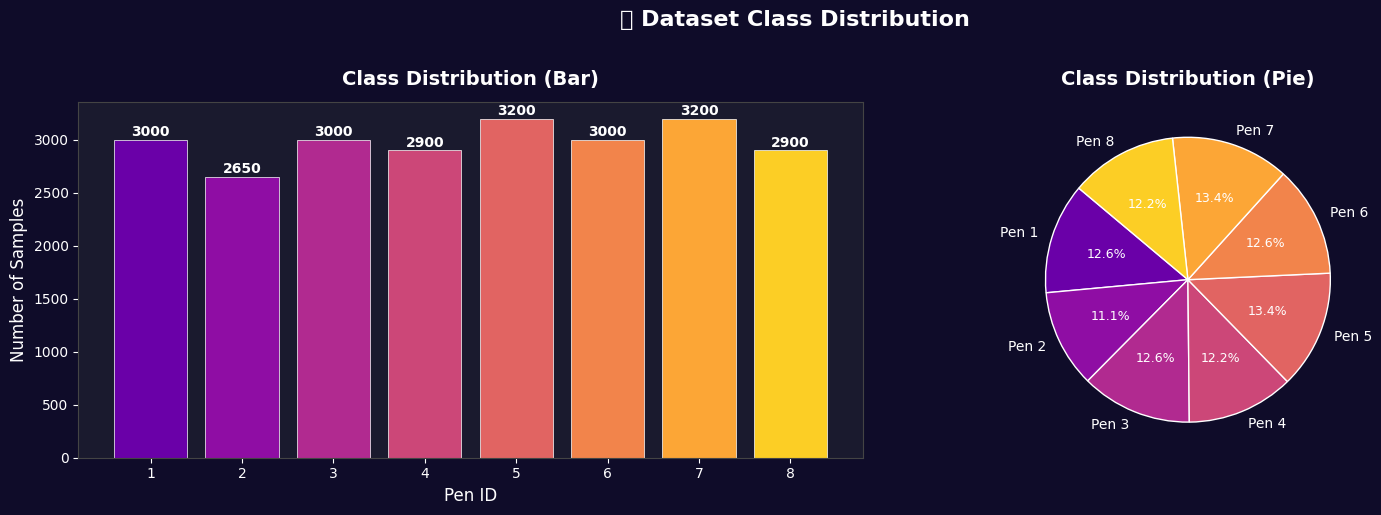

In [5]:
# ──────────────────────────────────────────────────────────────
# 📊 VISUALIZATION 1 — Class Distribution Bar Chart
# Useful for spotting class imbalance before training
# ──────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.patch.set_facecolor('#0f0c29')

counts = df['pen_id'].value_counts().sort_index()
colors = plt.cm.plasma(np.linspace(0.2, 0.9, len(counts)))

# Bar chart
ax1 = axes[0]
ax1.set_facecolor('#1a1a2e')
bars = ax1.bar(counts.index, counts.values, color=colors, edgecolor='white', linewidth=0.5)
ax1.set_title('Class Distribution (Bar)', color='white', fontsize=14, fontweight='bold', pad=12)
ax1.set_xlabel('Pen ID', color='white', fontsize=12)
ax1.set_ylabel('Number of Samples', color='white', fontsize=12)
ax1.tick_params(colors='white')
for spine in ax1.spines.values(): spine.set_edgecolor('#444')
for bar, val in zip(bars, counts.values):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
             str(val), ha='center', va='bottom', color='white', fontsize=10, fontweight='bold')

# Pie chart
ax2 = axes[1]
ax2.set_facecolor('#1a1a2e')
wedges, texts, autotexts = ax2.pie(
    counts.values,
    labels=[f'Pen {i}' for i in counts.index],
    autopct='%1.1f%%',
    colors=colors,
    startangle=140,
    wedgeprops=dict(edgecolor='white', linewidth=1)
)
for text in texts: text.set_color('white')
for at in autotexts: at.set_color('white'); at.set_fontsize(9)
ax2.set_title('Class Distribution (Pie)', color='white', fontsize=14, fontweight='bold', pad=12)

plt.suptitle('📊 Dataset Class Distribution', color='white', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150, bbox_inches='tight', facecolor='#0f0c29')
plt.show()

In [6]:
# ──────────────────────────────────────────────────────────────
# Merge base training CSV with the additional training CSV
# The additional set ships with the competition as extra labelled data
# ──────────────────────────────────────────────────────────────
train_df     = pd.read_csv(os.path.join(DATA_DIR, 'train.csv'))
add_train_df = pd.read_csv(os.path.join(DATA_DIR, 'additional_train.csv'))

# Stack both DataFrames row-wise and reset index
df = pd.concat([train_df, add_train_df], axis=0).reset_index(drop=True)

# Shift labels [1-8] → [0-7] for PyTorch compatibility
df['target'] = df['pen_id'] - 1

# ──────────────────────────────────────────────────────────────
# Stratified 80/20 train–validation split
# stratify ensures every class is equally represented in both sets
# ──────────────────────────────────────────────────────────────
train_df, val_df = train_test_split(
    df, test_size=0.2, random_state=42, stratify=df['target']
)

train_df = train_df.reset_index(drop=True)
val_df   = val_df.reset_index(drop=True)

print(f"Total merged data  : {len(df)}")
print(f"Training set size  : {len(train_df)}")
print(f"Validation set size: {len(val_df)}")

Total merged data  : 40250
Training set size  : 32200
Validation set size: 8050


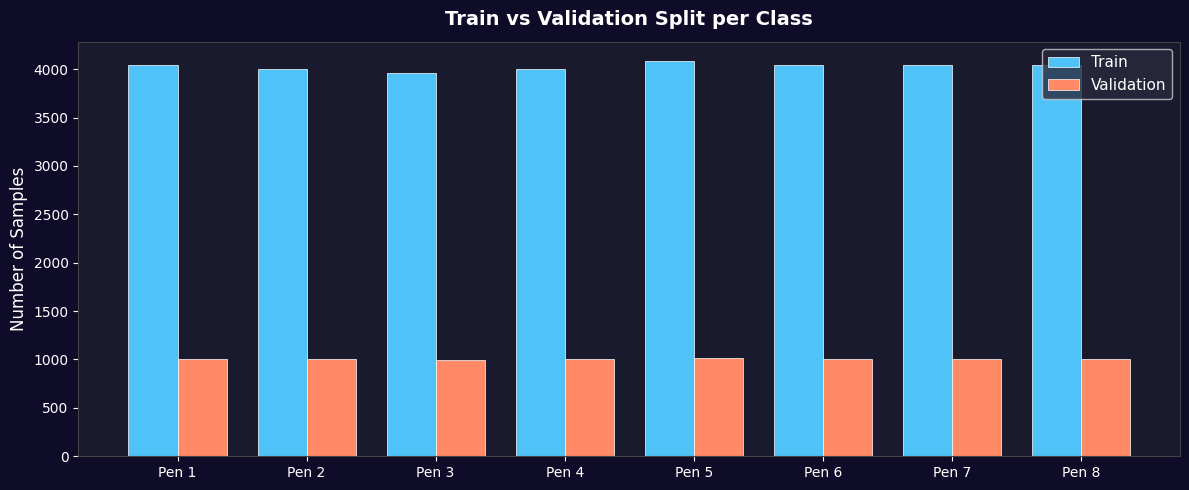

In [7]:
# ──────────────────────────────────────────────────────────────
# 📊 VISUALIZATION 2 — Train vs Validation Split per Class
# Confirms the stratified split is balanced across all classes
# ──────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 5))
fig.patch.set_facecolor('#0f0c29')
ax.set_facecolor('#1a1a2e')

train_counts = train_df['pen_id'].value_counts().sort_index()
val_counts   = val_df['pen_id'].value_counts().sort_index()

x = np.arange(len(train_counts))
w = 0.38

bars1 = ax.bar(x - w/2, train_counts.values, w, label='Train', color='#4fc3f7', edgecolor='white', linewidth=0.5)
bars2 = ax.bar(x + w/2, val_counts.values,   w, label='Validation', color='#ff8a65', edgecolor='white', linewidth=0.5)

ax.set_xticks(x)
ax.set_xticklabels([f'Pen {i}' for i in train_counts.index], color='white')
ax.set_title('Train vs Validation Split per Class', color='white', fontsize=14, fontweight='bold', pad=12)
ax.set_ylabel('Number of Samples', color='white', fontsize=12)
ax.tick_params(colors='white')
ax.legend(facecolor='#2a2a3e', labelcolor='white', fontsize=11)
for spine in ax.spines.values(): spine.set_edgecolor('#444')

plt.tight_layout()
plt.savefig('split_distribution.png', dpi=150, bbox_inches='tight', facecolor='#0f0c29')
plt.show()

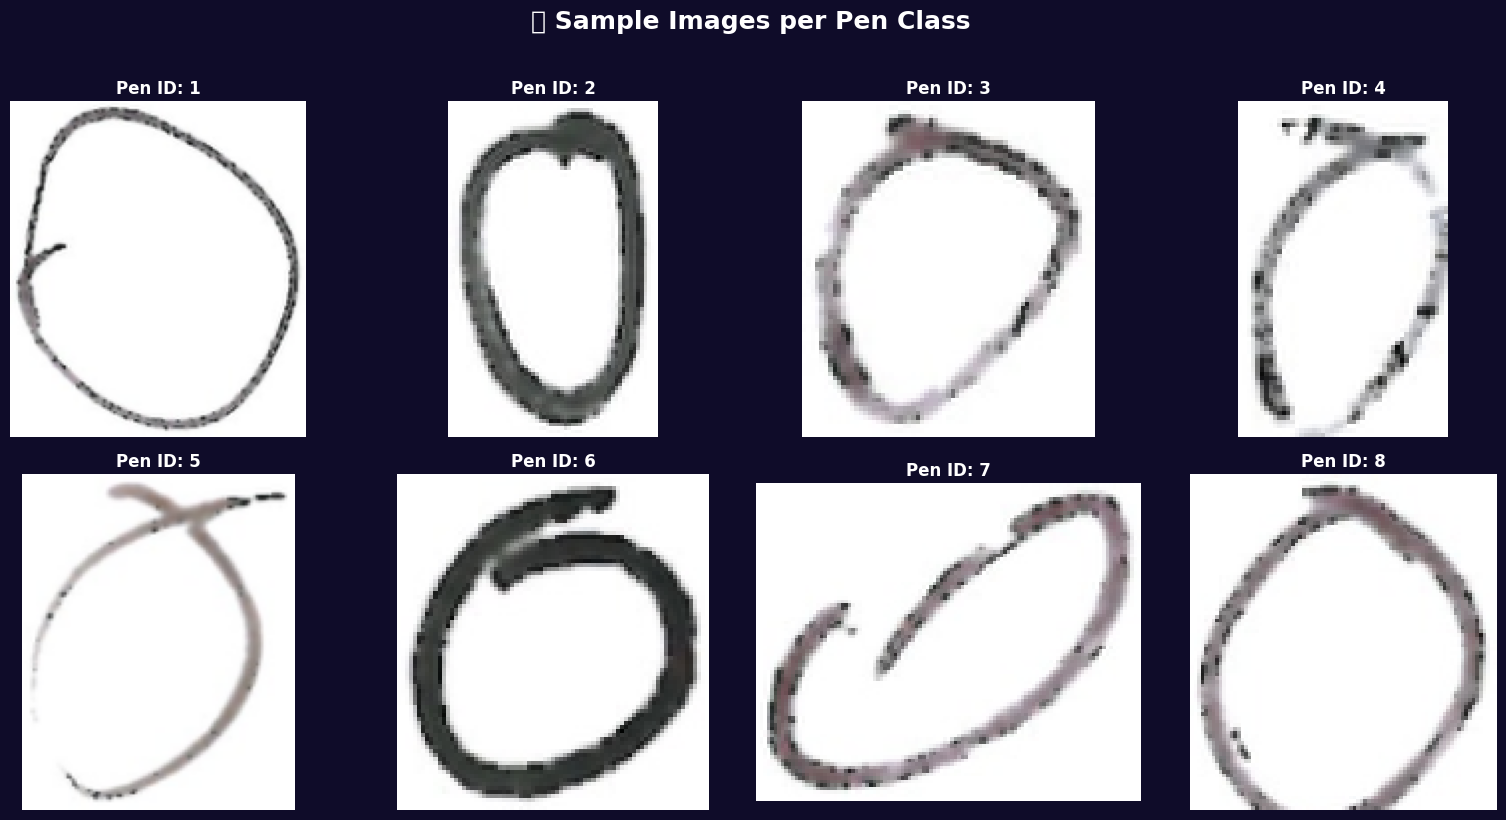

In [8]:
# ──────────────────────────────────────────────────────────────
# 📊 VISUALIZATION 3 — Sample Images from the Dataset
# Displays one random sample per pen class to understand input data
# ──────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
fig.patch.set_facecolor('#0f0c29')
plt.suptitle('🖊️ Sample Images per Pen Class', color='white', fontsize=18, fontweight='bold', y=1.02)

for pen_id, ax in zip(range(1, 9), axes.flatten()):
    sample = df[df['pen_id'] == pen_id].sample(1).iloc[0]
    img_name = sample['image_path']
    if 'images' not in img_name:
        img_path = os.path.join(DATA_DIR, 'images', img_name)
    else:
        img_path = os.path.join(DATA_DIR, img_name)

    try:
        img = Image.open(img_path).convert('RGB')
        ax.imshow(img)
    except Exception:
        ax.text(0.5, 0.5, 'Image not found', ha='center', va='center', color='white', transform=ax.transAxes)
        ax.set_facecolor('#1a1a2e')

    ax.set_title(f'Pen ID: {pen_id}', color='white', fontsize=12, fontweight='bold')
    ax.axis('off')
    for spine in ax.spines.values(): spine.set_edgecolor('#4fc3f7'); spine.set_linewidth(2)

plt.tight_layout()
plt.savefig('sample_images.png', dpi=150, bbox_inches='tight', facecolor='#0f0c29')
plt.show()

<div style="background: linear-gradient(135deg, #f7971e, #ffd200); padding: 40px 30px; margin: 20px 0; border-radius: 16px; box-shadow: 0 4px 20px rgba(0,0,0,0.4); text-align: center;">
  <h2 style="color: #1a1a2e; font-family: 'Arial Black', Arial, sans-serif; font-size: 28px; margin: 0; letter-spacing: 1px;">🔄 SECTION 3 — DATASET & DATALOADERS</h2>
</div>

In [9]:
class CircleIDDataset(Dataset):
    """
    Custom PyTorch Dataset for the CircleID pen-classification task.

    Args:
        df         : DataFrame with 'image_path' column (and 'target' for train/val).
        data_dir   : Root directory that contains the 'images/' subfolder.
        transforms : torchvision transform pipeline applied to each image.
        is_test    : If True, __getitem__ returns only the image tensor (no label).
    """

    def __init__(self, df, data_dir, transforms=None, is_test=False):
        self.df         = df
        self.data_dir   = data_dir
        self.transforms = transforms
        self.is_test    = is_test

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        # Retrieve the image file name from the CSV
        img_name = self.df.iloc[idx]['image_path']

        # Build the full file path — handle CSVs that already include 'images/'
        if 'images' not in img_name:
            img_path = os.path.join(self.data_dir, 'images', img_name)
        else:
            img_path = os.path.join(self.data_dir, img_name)

        # Open image and convert to RGB (handles grayscale / RGBA edge cases)
        image = Image.open(img_path).convert('RGB')

        # Apply augmentation / normalization transforms
        if self.transforms:
            image = self.transforms(image)

        # Return image-only for test inference; image + label for training
        if self.is_test:
            return image
        else:
            label = self.df.iloc[idx]['target']
            return image, torch.tensor(label, dtype=torch.long)

In [10]:
# ─────────────────────────────────────────────────────────────────────
# Hyperparameters
# IMG_SIZE  : Standard input resolution for EfficientNet and most timm models
# BATCH_SIZE: Tuned for GPU VRAM — reduce if you hit OOM errors
# ─────────────────────────────────────────────────────────────────────
IMG_SIZE   = 224
BATCH_SIZE = 128

# ─────────────────────────────────────────────────────────────────────
# Training transforms — aggressive augmentations to improve generalisation
# ─────────────────────────────────────────────────────────────────────
train_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),        # Randomly mirror horizontally
    transforms.RandomVerticalFlip(),          # Randomly mirror vertically
    transforms.RandomRotation(20),            # Random rotation up to ±20°
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2),  # Colour augmentation
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])   # ImageNet statistics
])

# ─────────────────────────────────────────────────────────────────────
# Validation / Test transforms — NO augmentation, just resize & normalize
# ─────────────────────────────────────────────────────────────────────
val_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# Build Dataset objects
train_dataset = CircleIDDataset(train_df, DATA_DIR, transforms=train_transforms)
val_dataset   = CircleIDDataset(val_df,   DATA_DIR, transforms=val_transforms)

# ─────────────────────────────────────────────────────────────────────
# DataLoaders — num_workers=0 & pin_memory=False avoids multi-GPU deadlocks
# ─────────────────────────────────────────────────────────────────────
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE,
                          shuffle=True,  num_workers=0, pin_memory=False)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE,
                          shuffle=False, num_workers=0, pin_memory=False)

print(f"✅ DataLoaders ready.")
print(f"   Train batches per epoch : {len(train_loader)}")
print(f"   Val   batches per epoch : {len(val_loader)}")

✅ DataLoaders ready.
   Train batches per epoch : 252
   Val   batches per epoch : 63


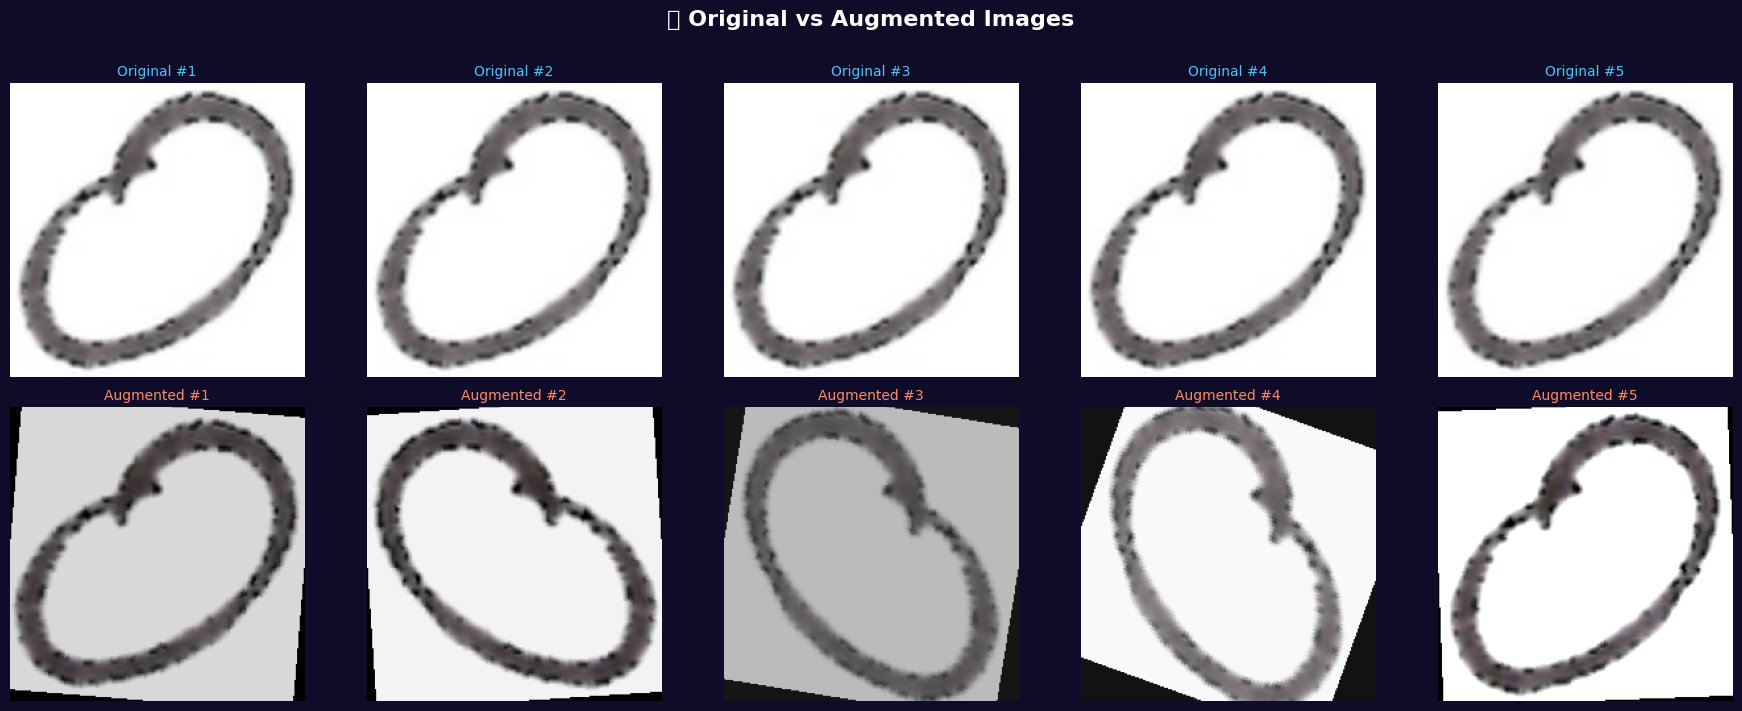

In [11]:
# ──────────────────────────────────────────────────────────────
# 📊 VISUALIZATION 4 — Augmented vs Original Image Comparison
# Shows what the model actually 'sees' after augmentation
# ──────────────────────────────────────────────────────────────
IMAGENET_MEAN = np.array([0.485, 0.456, 0.406])
IMAGENET_STD  = np.array([0.229, 0.224, 0.225])

def denormalize(tensor):
    """Convert a normalised tensor back to a displayable numpy image."""
    img = tensor.permute(1, 2, 0).numpy()
    return np.clip(img * IMAGENET_STD + IMAGENET_MEAN, 0, 1)

fig, axes = plt.subplots(2, 5, figsize=(18, 7))
fig.patch.set_facecolor('#0f0c29')
plt.suptitle('🔄 Original vs Augmented Images', color='white', fontsize=16, fontweight='bold', y=1.01)

sample_row = df.sample(1).iloc[0]
img_name   = sample_row['image_path']
img_path   = os.path.join(DATA_DIR, 'images', img_name) if 'images' not in img_name else os.path.join(DATA_DIR, img_name)

try:
    orig_img = Image.open(img_path).convert('RGB')
    orig_resized = orig_img.resize((IMG_SIZE, IMG_SIZE))

    # Top row: original
    for i, ax in enumerate(axes[0]):
        ax.imshow(orig_resized)
        ax.set_title(f'Original #{i+1}', color='#4fc3f7', fontsize=10)
        ax.axis('off')

    # Bottom row: five different augmented versions
    for i, ax in enumerate(axes[1]):
        aug_tensor = train_transforms(orig_img)
        ax.imshow(denormalize(aug_tensor))
        ax.set_title(f'Augmented #{i+1}', color='#ff8a65', fontsize=10)
        ax.axis('off')
except Exception:
    print("⚠️  Sample image not found — skipping augmentation preview.")

plt.tight_layout()
plt.savefig('augmentation_preview.png', dpi=150, bbox_inches='tight', facecolor='#0f0c29')
plt.show()

<div style="background: linear-gradient(135deg, #8e2de2, #4a00e0); padding: 40px 30px; margin: 20px 0; border-radius: 16px; box-shadow: 0 4px 20px rgba(0,0,0,0.5); text-align: center;">
  <h2 style="color: white; font-family: 'Arial Black', Arial, sans-serif; font-size: 28px; margin: 0; letter-spacing: 1px;">🧠 SECTION 4 — MODEL ARCHITECTURE</h2>
</div>

In [12]:
# ─────────────────────────────────────────────────────────────────────
# Build EfficientNet-B0 with ImageNet pretrained weights via timm
# num_classes=8 replaces the original 1000-class head with our 8-class head
# ─────────────────────────────────────────────────────────────────────
MODEL_NAME  = 'efficientnet_b0'
NUM_CLASSES = 8

model = timm.create_model(MODEL_NAME, pretrained=True, num_classes=NUM_CLASSES)

# Wrap with DataParallel if multiple GPUs are available
if torch.cuda.device_count() > 1:
    print(f"🔥 {torch.cuda.device_count()} GPUs detected! Activating DataParallel.")
    model = nn.DataParallel(model)

model = model.to(device)

# Count total and trainable parameters
total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"✅ {MODEL_NAME} loaded successfully.")
print(f"   Total parameters    : {total_params:,}")
print(f"   Trainable parameters: {trainable_params:,}")

model.safetensors:   0%|          | 0.00/21.4M [00:00<?, ?B/s]

🔥 2 GPUs detected! Activating DataParallel.
✅ efficientnet_b0 loaded successfully.
   Total parameters    : 4,017,796
   Trainable parameters: 4,017,796


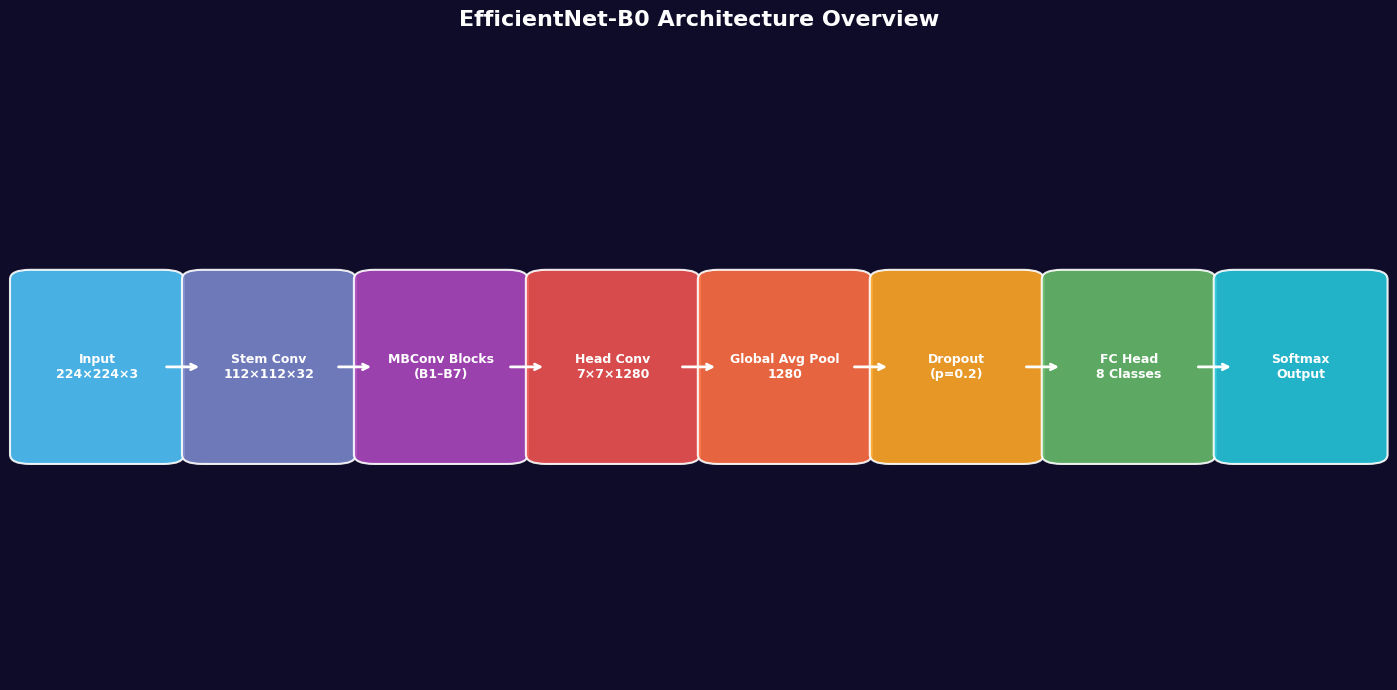

In [13]:
# ──────────────────────────────────────────────────────────────
# 📊 VISUALIZATION 5 — EfficientNet-B0 Architecture Summary
# Visual block diagram of the high-level layer structure
# ──────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 7))
fig.patch.set_facecolor('#0f0c29')
ax.set_facecolor('#0f0c29')
ax.axis('off')

blocks = [
    ("Input\n224×224×3",      '#4fc3f7'),
    ("Stem Conv\n112×112×32", '#7986cb'),
    ("MBConv Blocks\n(B1–B7)", '#ab47bc'),
    ("Head Conv\n7×7×1280",   '#ef5350'),
    ("Global Avg Pool\n1280",  '#ff7043'),
    ("Dropout\n(p=0.2)",       '#ffa726'),
    ("FC Head\n8 Classes",     '#66bb6a'),
    ("Softmax\nOutput",        '#26c6da'),
]

n   = len(blocks)
xs  = np.linspace(0.05, 0.95, n)
y   = 0.5
bw, bh = 0.10, 0.28

for i, (label, color) in enumerate(blocks):
    rect = mpatches.FancyBboxPatch((xs[i]-bw/2, y-bh/2), bw, bh,
                                   boxstyle="round,pad=0.015",
                                   facecolor=color, edgecolor='white',
                                   linewidth=1.5, alpha=0.9,
                                   transform=ax.transAxes, clip_on=False)
    ax.add_patch(rect)
    ax.text(xs[i], y, label, ha='center', va='center',
            fontsize=9, fontweight='bold', color='white',
            transform=ax.transAxes, multialignment='center')
    if i < n - 1:
        ax.annotate('', xy=(xs[i+1]-bw/2, y), xytext=(xs[i]+bw/2, y),
                    xycoords='axes fraction', textcoords='axes fraction',
                    arrowprops=dict(arrowstyle='->', color='white', lw=2))

ax.set_title('EfficientNet-B0 Architecture Overview', color='white',
             fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('model_architecture.png', dpi=150, bbox_inches='tight', facecolor='#0f0c29')
plt.show()

<div style="background: linear-gradient(135deg, #e52d27, #b31217); padding: 40px 30px; margin: 20px 0; border-radius: 16px; box-shadow: 0 4px 20px rgba(0,0,0,0.5); text-align: center;">
  <h2 style="color: white; font-family: 'Arial Black', Arial, sans-serif; font-size: 28px; margin: 0; letter-spacing: 1px;">🚀 SECTION 5 — TRAINING</h2>
</div>

In [14]:
# ─────────────────────────────────────────────────────────────────────
# Loss function: CrossEntropyLoss — standard for multi-class classification
#
# Optimiser: AdamW — Adam with decoupled weight decay;
#            widely used in modern vision/NLP fine-tuning tasks
#
# Scheduler: ReduceLROnPlateau — halves the LR if val accuracy does not
#            improve for 2 consecutive epochs, enabling finer convergence
# ─────────────────────────────────────────────────────────────────────
criterion = nn.CrossEntropyLoss()

optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='max', factor=0.5, patience=2
)

In [15]:
import time

EPOCHS                  = 50
EARLY_STOPPING_PATIENCE = 7   # Stop training if val accuracy stalls for this many epochs

patience_counter = 0
best_val_acc     = 0.0

# ─────────────────────────────────────────────
# Containers for learning curve visualisation
# ─────────────────────────────────────────────
history = {
    'train_loss': [], 'val_loss': [],
    'train_acc' : [], 'val_acc' : [],
    'lr'        : []
}

for epoch in range(EPOCHS):
    epoch_start = time.time()
    print(f"\nEpoch {epoch+1}/{EPOCHS}")
    print("-" * 40)

    # ───────────── TRAIN PHASE ─────────────
    model.train()
    running_loss     = 0.0
    running_corrects = 0

    train_bar = tqdm(train_loader, desc='  Training', leave=False)
    for inputs, labels in train_bar:
        inputs = inputs.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        with torch.set_grad_enabled(True):
            outputs = model(inputs)
            loss    = criterion(outputs, labels)
            _, preds = torch.max(outputs, 1)
            loss.backward()
            optimizer.step()

        running_loss     += loss.item() * inputs.size(0)
        running_corrects += torch.sum(preds == labels.data)

    epoch_loss = running_loss / len(train_dataset)
    epoch_acc  = running_corrects.double() / len(train_dataset)
    print(f"  Train  — Loss: {epoch_loss:.4f} | Acc: {epoch_acc:.4f}")

    # ───────────── VALIDATION PHASE ────────
    model.eval()
    val_loss      = 0.0
    val_corrects  = 0

    val_bar = tqdm(val_loader, desc='  Validating', leave=False)
    for inputs, labels in val_bar:
        inputs = inputs.to(device)
        labels = labels.to(device)
        with torch.set_grad_enabled(False):
            outputs = model(inputs)
            loss    = criterion(outputs, labels)
            _, preds = torch.max(outputs, 1)
        val_loss     += loss.item() * inputs.size(0)
        val_corrects += torch.sum(preds == labels.data)

    val_epoch_loss = val_loss / len(val_dataset)
    val_epoch_acc  = val_corrects.double() / len(val_dataset)
    print(f"  Val    — Loss: {val_epoch_loss:.4f} | Acc: {val_epoch_acc:.4f}")

    elapsed = time.time() - epoch_start
    print(f"  ⏱  Epoch time: {elapsed:.1f}s | LR: {optimizer.param_groups[0]['lr']:.2e}")

    # Record metrics for plotting
    history['train_loss'].append(epoch_loss)
    history['val_loss'].append(val_epoch_loss)
    history['train_acc'].append(float(epoch_acc))
    history['val_acc'].append(float(val_epoch_acc))
    history['lr'].append(optimizer.param_groups[0]['lr'])

    scheduler.step(val_epoch_acc)

    # ───────────── EARLY STOPPING & CHECKPOINT ─────────────
    if val_epoch_acc > best_val_acc:
        best_val_acc = val_epoch_acc
        torch.save(model.state_dict(), 'best_model.pth')
        print(f"  🚀 New best model saved! (Val Acc: {best_val_acc:.4f})")
        patience_counter = 0
    else:
        patience_counter += 1
        print(f"  ⚠️  No improvement. Patience: {patience_counter}/{EARLY_STOPPING_PATIENCE}")

    if patience_counter >= EARLY_STOPPING_PATIENCE:
        print("\n🛑 Early stopping triggered — training complete.")
        break

print(f"\n✅ Training finished. Best validation accuracy: {best_val_acc:.4f}")


Epoch 1/50
----------------------------------------


  Training:   0%|          | 0/252 [00:00<?, ?it/s]

  Train  — Loss: 0.4659 | Acc: 0.8094


  Validating:   0%|          | 0/63 [00:00<?, ?it/s]

  Val    — Loss: 0.2628 | Acc: 0.8867
  ⏱  Epoch time: 498.1s | LR: 1.00e-03
  🚀 New best model saved! (Val Acc: 0.8867)

Epoch 2/50
----------------------------------------


...

  Val    — Loss: 0.1463 | Acc: 0.9692
  ⏱  Epoch time: 276.0s | LR: 3.13e-05
  ⚠️  No improvement. Patience: 6/7

Epoch 38/50
----------------------------------------


  Training:   0%|          | 0/252 [00:00<?, ?it/s]

  Train  — Loss: 0.0025 | Acc: 0.9992


  Validating:   0%|          | 0/63 [00:00<?, ?it/s]

  Val    — Loss: 0.1471 | Acc: 0.9678
  ⏱  Epoch time: 278.5s | LR: 1.56e-05
  ⚠️  No improvement. Patience: 7/7

🛑 Early stopping triggered — training complete.

✅ Training finished. Best validation accuracy: 0.9698


<div style="background: linear-gradient(135deg, #0f2027, #203a43, #2c5364); padding: 40px 30px; margin: 20px 0; border-radius: 16px; box-shadow: 0 4px 20px rgba(0,0,0,0.5); text-align: center;">
  <h2 style="color: white; font-family: 'Arial Black', Arial, sans-serif; font-size: 28px; margin: 0; letter-spacing: 1px;">📈 SECTION 6 — TRAINING VISUALIZATIONS</h2>
</div>

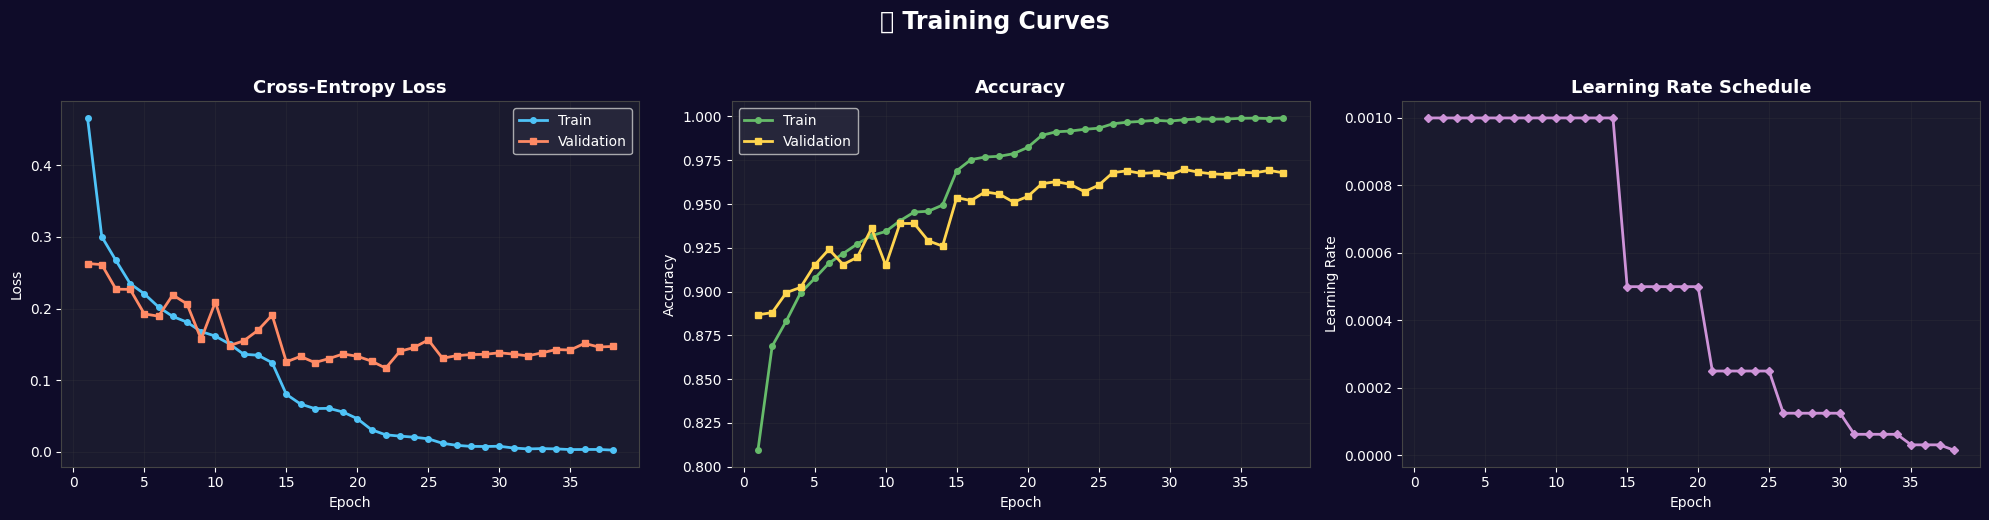

In [16]:
# ──────────────────────────────────────────────────────────────
# 📊 VISUALIZATION 6 — Training & Validation Learning Curves
# ──────────────────────────────────────────────────────────────
epochs_ran = list(range(1, len(history['train_loss']) + 1))

fig, axes = plt.subplots(1, 3, figsize=(20, 5))
fig.patch.set_facecolor('#0f0c29')

plot_cfg = [
    ('train_loss', 'val_loss',  '#4fc3f7', '#ff8a65', 'Loss',     'Cross-Entropy Loss'),
    ('train_acc',  'val_acc',   '#66bb6a', '#ffd54f', 'Accuracy', 'Accuracy'),
]

for ax, (tk, vk, tc, vc, ylabel, title) in zip(axes[:2], plot_cfg):
    ax.set_facecolor('#1a1a2e')
    ax.plot(epochs_ran, history[tk], color=tc, lw=2, marker='o', ms=4, label='Train')
    ax.plot(epochs_ran, history[vk], color=vc, lw=2, marker='s', ms=4, label='Validation')
    ax.set_title(title, color='white', fontsize=13, fontweight='bold')
    ax.set_xlabel('Epoch', color='white')
    ax.set_ylabel(ylabel, color='white')
    ax.legend(facecolor='#2a2a3e', labelcolor='white')
    ax.tick_params(colors='white')
    ax.grid(True, alpha=0.2, color='#444')
    for spine in ax.spines.values(): spine.set_edgecolor('#444')

# Learning rate schedule
ax3 = axes[2]
ax3.set_facecolor('#1a1a2e')
ax3.plot(epochs_ran, history['lr'], color='#ce93d8', lw=2, marker='D', ms=4)
ax3.set_title('Learning Rate Schedule', color='white', fontsize=13, fontweight='bold')
ax3.set_xlabel('Epoch', color='white')
ax3.set_ylabel('Learning Rate', color='white')
ax3.tick_params(colors='white')
ax3.grid(True, alpha=0.2, color='#444')
for spine in ax3.spines.values(): spine.set_edgecolor('#444')

plt.suptitle('📈 Training Curves', color='white', fontsize=17, fontweight='bold', y=1.03)
plt.tight_layout()
plt.savefig('training_curves.png', dpi=150, bbox_inches='tight', facecolor='#0f0c29')
plt.show()

Generating confusion matrix:   0%|          | 0/63 [00:00<?, ?it/s]

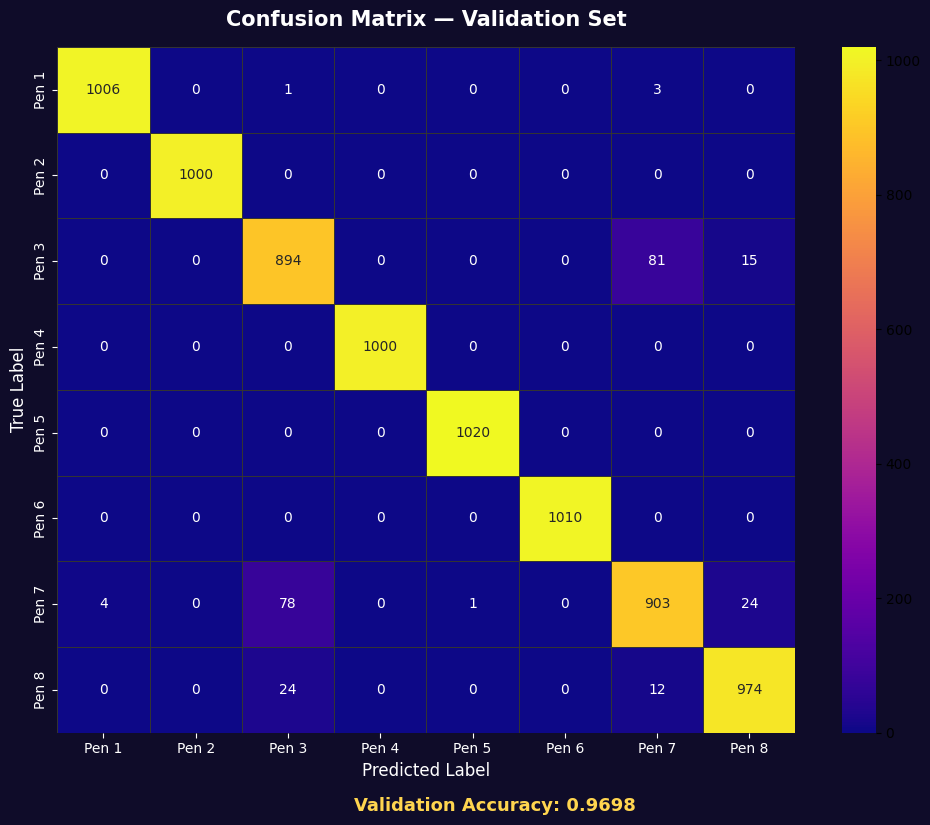


📋 Classification Report:
              precision    recall  f1-score   support

       Pen 1       1.00      1.00      1.00      1010
       Pen 2       1.00      1.00      1.00      1000
       Pen 3       0.90      0.90      0.90       990
       Pen 4       1.00      1.00      1.00      1000
       Pen 5       1.00      1.00      1.00      1020
       Pen 6       1.00      1.00      1.00      1010
       Pen 7       0.90      0.89      0.90      1010
       Pen 8       0.96      0.96      0.96      1010

    accuracy                           0.97      8050
   macro avg       0.97      0.97      0.97      8050
weighted avg       0.97      0.97      0.97      8050



In [17]:
# ──────────────────────────────────────────────────────────────
# 📊 VISUALIZATION 7 — Confusion Matrix on Validation Set
# Load best checkpoint, run inference on val set, plot confusion matrix
# ──────────────────────────────────────────────────────────────
model.load_state_dict(torch.load('best_model.pth'))
model.eval()

all_preds  = []
all_labels = []

with torch.no_grad():
    for inputs, labels in tqdm(val_loader, desc='Generating confusion matrix'):
        inputs = inputs.to(device)
        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

cm = confusion_matrix(all_labels, all_preds)

fig, ax = plt.subplots(figsize=(10, 8))
fig.patch.set_facecolor('#0f0c29')
ax.set_facecolor('#1a1a2e')

sns.heatmap(
    cm,
    annot=True, fmt='d', cmap='plasma',
    xticklabels=[f'Pen {i}' for i in range(1, 9)],
    yticklabels=[f'Pen {i}' for i in range(1, 9)],
    linewidths=0.5, linecolor='#333',
    ax=ax
)

ax.set_title('Confusion Matrix — Validation Set', color='white', fontsize=15, fontweight='bold', pad=15)
ax.set_xlabel('Predicted Label', color='white', fontsize=12)
ax.set_ylabel('True Label', color='white', fontsize=12)
ax.tick_params(colors='white')

val_accuracy = accuracy_score(all_labels, all_preds)
plt.figtext(0.5, -0.02, f'Validation Accuracy: {val_accuracy:.4f}',
            ha='center', color='#ffd54f', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight', facecolor='#0f0c29')
plt.show()

print("\n📋 Classification Report:")
print(classification_report(
    all_labels, all_preds,
    target_names=[f'Pen {i}' for i in range(1, 9)]
))

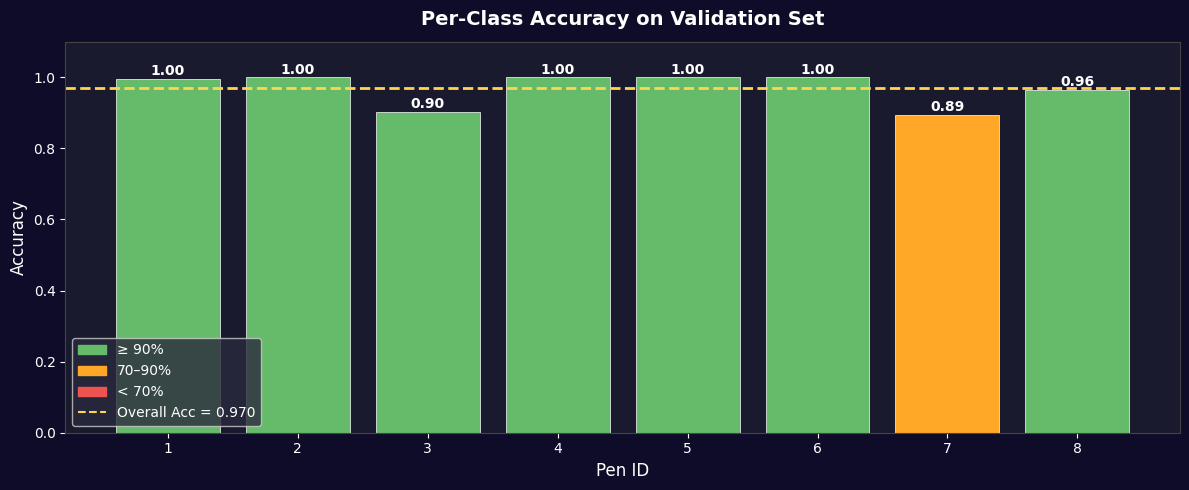

In [18]:
# ──────────────────────────────────────────────────────────────
# 📊 VISUALIZATION 8 — Per-Class Accuracy Bar Chart
# Highlights which pen classes the model finds hardest
# ──────────────────────────────────────────────────────────────
per_class_acc = cm.diagonal() / cm.sum(axis=1)

fig, ax = plt.subplots(figsize=(12, 5))
fig.patch.set_facecolor('#0f0c29')
ax.set_facecolor('#1a1a2e')

colors = ['#66bb6a' if v >= 0.9 else '#ffa726' if v >= 0.7 else '#ef5350' for v in per_class_acc]
bars = ax.bar(range(1, 9), per_class_acc, color=colors, edgecolor='white', linewidth=0.5)
ax.axhline(y=val_accuracy, color='#ffd54f', linestyle='--', linewidth=2, label=f'Overall Acc = {val_accuracy:.3f}')

for bar, val in zip(bars, per_class_acc):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{val:.2f}', ha='center', color='white', fontsize=10, fontweight='bold')

legend_patches = [
    mpatches.Patch(color='#66bb6a', label='≥ 90%'),
    mpatches.Patch(color='#ffa726', label='70–90%'),
    mpatches.Patch(color='#ef5350', label='< 70%'),
]
ax.legend(handles=legend_patches + [plt.Line2D([0], [0], color='#ffd54f', linestyle='--', label=f'Overall Acc = {val_accuracy:.3f}')],
          facecolor='#2a2a3e', labelcolor='white', fontsize=10)

ax.set_title('Per-Class Accuracy on Validation Set', color='white', fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel('Pen ID', color='white', fontsize=12)
ax.set_ylabel('Accuracy', color='white', fontsize=12)
ax.set_ylim(0, 1.1)
ax.set_xticks(range(1, 9))
ax.tick_params(colors='white')
for spine in ax.spines.values(): spine.set_edgecolor('#444')

plt.tight_layout()
plt.savefig('per_class_accuracy.png', dpi=150, bbox_inches='tight', facecolor='#0f0c29')
plt.show()

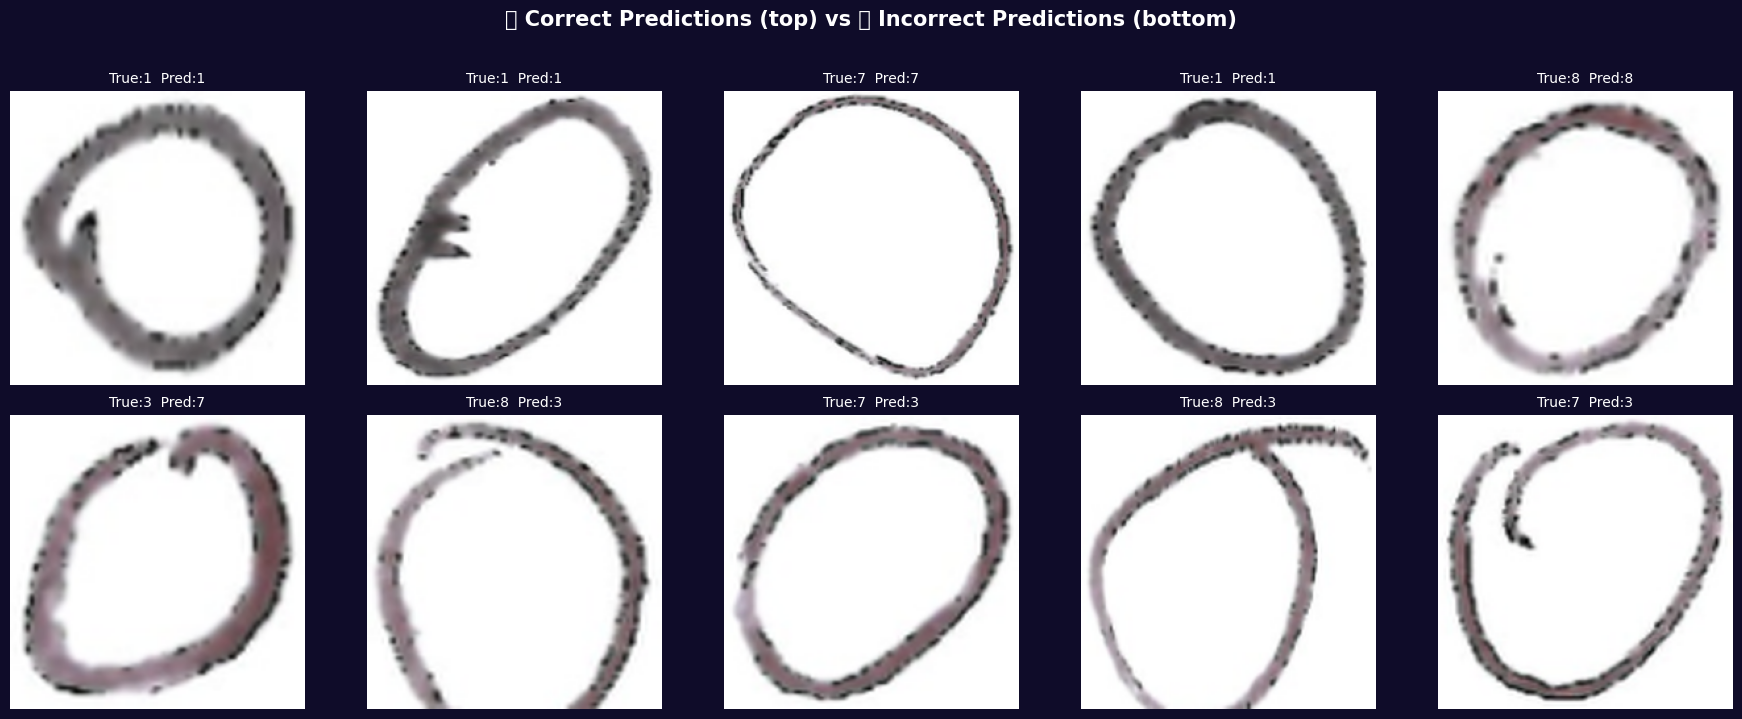

In [19]:
# ──────────────────────────────────────────────────────────────
# 📊 VISUALIZATION 9 — Correct vs Incorrect Predictions Grid
# Samples from the validation set showing model successes and failures
# ──────────────────────────────────────────────────────────────
correct_idx   = [i for i, (p, l) in enumerate(zip(all_preds, all_labels)) if p == l][:5]
incorrect_idx = [i for i, (p, l) in enumerate(zip(all_preds, all_labels)) if p != l][:5]

fig, axes = plt.subplots(2, 5, figsize=(18, 7))
fig.patch.set_facecolor('#0f0c29')
plt.suptitle('✅ Correct Predictions (top) vs ❌ Incorrect Predictions (bottom)',
             color='white', fontsize=15, fontweight='bold', y=1.02)

def show_sample(ax, idx, row_set, border_color):
    row = val_df.iloc[idx]
    img_name = row['image_path']
    img_path = os.path.join(DATA_DIR, 'images', img_name) if 'images' not in img_name else os.path.join(DATA_DIR, img_name)
    try:
        img = Image.open(img_path).convert('RGB').resize((IMG_SIZE, IMG_SIZE))
        ax.imshow(img)
    except Exception:
        ax.set_facecolor('#333')
    true_id = all_labels[idx] + 1
    pred_id = all_preds[idx]  + 1
    ax.set_title(f'True:{true_id}  Pred:{pred_id}', color='white', fontsize=10)
    ax.axis('off')
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_edgecolor(border_color)
        spine.set_linewidth(3)

for i, idx in enumerate(correct_idx):
    show_sample(axes[0][i], idx, val_df, '#66bb6a')
for i, idx in enumerate(incorrect_idx):
    show_sample(axes[1][i], idx, val_df, '#ef5350')

plt.tight_layout()
plt.savefig('pred_samples.png', dpi=150, bbox_inches='tight', facecolor='#0f0c29')
plt.show()

<div style="background: linear-gradient(135deg, #134e5e, #71b280); padding: 40px 30px; margin: 20px 0; border-radius: 16px; box-shadow: 0 4px 20px rgba(0,0,0,0.4); text-align: center;">
  <h2 style="color: white; font-family: 'Arial Black', Arial, sans-serif; font-size: 28px; margin: 0; letter-spacing: 1px;">📤 SECTION 7 — INFERENCE & SUBMISSION</h2>
</div>

In [20]:
# Read the competition test CSV (v2 test set is already included)
test_df = pd.read_csv(os.path.join(DATA_DIR, 'test.csv'))

# Build test Dataset and DataLoader
# is_test=True — no labels, so __getitem__ returns only the image tensor
# We can double the batch size during inference (no backprop → less VRAM used)
test_dataset = CircleIDDataset(test_df, DATA_DIR, transforms=val_transforms, is_test=True)
test_loader  = DataLoader(test_dataset, batch_size=BATCH_SIZE * 2,
                          shuffle=False, num_workers=2, pin_memory=True)

print(f"✅ Test data ready. Total images to predict: {len(test_df)}")

✅ Test data ready. Total images to predict: 5905


In [21]:
# Load the best checkpoint saved during training
model.load_state_dict(torch.load('best_model.pth'))
model.eval()

predictions = []

test_bar = tqdm(test_loader, desc='Running Inference')
for inputs in test_bar:
    inputs = inputs.to(device)
    with torch.no_grad():           # Disable gradient computation to save memory
        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)

        # PyTorch predicts [0-7]; competition expects pen_id [1-8] → add 1
        preds = preds.cpu().numpy() + 1
        predictions.extend(preds)

# Build submission DataFrame in the required format
submission_df = pd.DataFrame({
    'image_id': test_df['image_id'],
    'pen_id'  : predictions
})

# Export to CSV — appears in Kaggle's Output panel on the right
submission_df.to_csv('submission_pen.csv', index=False)

print("✅ submission_pen.csv created successfully!")
submission_df.head()

Running Inference:   0%|          | 0/24 [00:00<?, ?it/s]

✅ submission_pen.csv created successfully!


,image_id,pen_id
0,v2_8eb750cb7bac5c42036af72b8253976b,2
1,v2_04e19b0acea03fe2ae474ce8a4c6b705,8
2,v2_6b3400d5252124adcc9859cbc78c5d8a,1
3,v2_79025cb2ef36af3dc15c91056fa225dc,8
4,v2_3ed2f62c32c69ec191b7e5b86433cb87,5


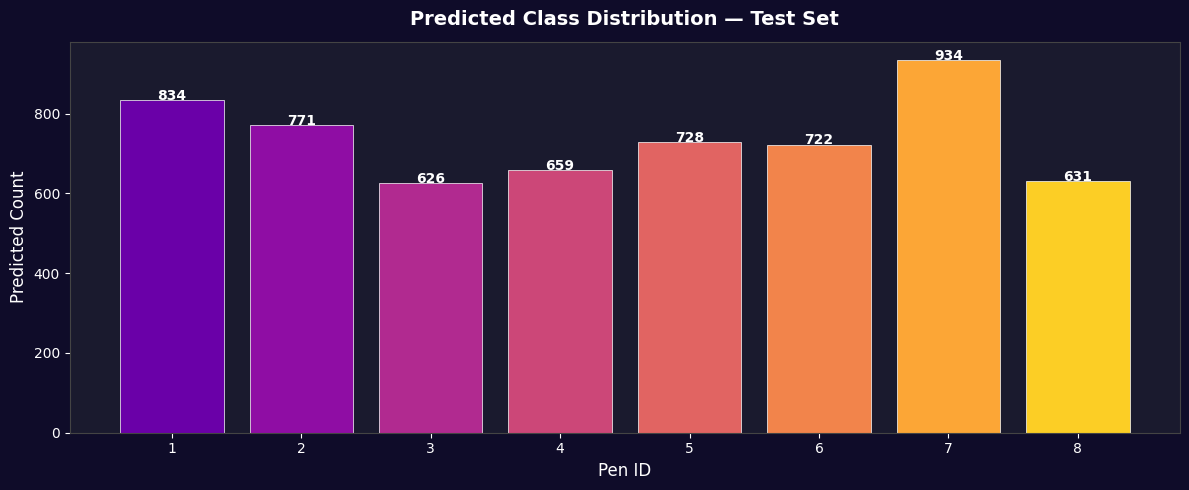

In [22]:
# ──────────────────────────────────────────────────────────────
# 📊 VISUALIZATION 10 — Predicted Class Distribution (Test Set)
# A sanity check: predicted labels should be roughly balanced
# if the test set mirrors the training distribution
# ──────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 5))
fig.patch.set_facecolor('#0f0c29')
ax.set_facecolor('#1a1a2e')

pred_counts = submission_df['pen_id'].value_counts().sort_index()
colors = plt.cm.plasma(np.linspace(0.2, 0.9, len(pred_counts)))
bars = ax.bar(pred_counts.index, pred_counts.values, color=colors, edgecolor='white', linewidth=0.5)

for bar, val in zip(bars, pred_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            str(val), ha='center', color='white', fontsize=10, fontweight='bold')

ax.set_title('Predicted Class Distribution — Test Set', color='white', fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel('Pen ID', color='white', fontsize=12)
ax.set_ylabel('Predicted Count', color='white', fontsize=12)
ax.set_xticks(range(1, 9))
ax.tick_params(colors='white')
for spine in ax.spines.values(): spine.set_edgecolor('#444')

plt.tight_layout()
plt.savefig('prediction_distribution.png', dpi=150, bbox_inches='tight', facecolor='#0f0c29')
plt.show()

<div style="background: linear-gradient(135deg, #0f0c29, #302b63, #24243e); padding: 50px 30px; margin: 30px 0; border-radius: 20px; box-shadow: 0 8px 32px rgba(0,0,0,0.5); border: 2px solid rgba(255,255,255,0.1); text-align: center;">
  <div style="font-size: 50px; margin-bottom: 12px;">🏆</div>
  <h2 style="color: white; font-family: 'Arial Black', Arial, sans-serif; font-size: 32px; font-weight: 900; margin: 0 0 12px 0;">All Done!</h2>
  <p style="color: rgba(255,255,255,0.75); font-size: 16px; margin: 0 0 20px 0; font-family: Arial, sans-serif; line-height: 1.7;">Your <strong style='color:white'>submission_pen.csv</strong> is ready to upload. Good luck on the leaderboard! 🚀</p>
  <div style="display: inline-flex; gap: 12px; flex-wrap: wrap; justify-content: center;">
    <span style="background: rgba(255,255,255,0.12); color: white; padding: 6px 18px; border-radius: 30px; font-size: 14px; border: 1px solid rgba(255,255,255,0.2);">✅ EfficientNet-B0</span>
    <span style="background: rgba(255,255,255,0.12); color: white; padding: 6px 18px; border-radius: 30px; font-size: 14px; border: 1px solid rgba(255,255,255,0.2);">✅ Early Stopping</span>
    <span style="background: rgba(255,255,255,0.12); color: white; padding: 6px 18px; border-radius: 30px; font-size: 14px; border: 1px solid rgba(255,255,255,0.2);">✅ 10 Visualizations</span>
    <span style="background: rgba(255,255,255,0.12); color: white; padding: 6px 18px; border-radius: 30px; font-size: 14px; border: 1px solid rgba(255,255,255,0.2);">✅ Submission Ready</span>
  </div>
</div>